In [2]:
import gdown, os

GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1lRUA-1uCCXfks8kpypFV-4f0UepWoLkU?usp=sharing"
EXTRACT_TO = "/kaggle/working/cig_ps"

gdown.download_folder(GDRIVE_FOLDER_URL, output=EXTRACT_TO, quiet=False, use_cookies=False)

print(os.listdir(EXTRACT_TO))

Retrieving folder contents


Processing file 1e0Bpbmjp-Pc1Oz7luC1g8JhfzKpGZRHu cig_ps.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1e0Bpbmjp-Pc1Oz7luC1g8JhfzKpGZRHu
From (redirected): https://drive.google.com/uc?id=1e0Bpbmjp-Pc1Oz7luC1g8JhfzKpGZRHu&confirm=t&uuid=11f5ed77-92ea-4715-bf90-7648814f0555
To: /kaggle/working/cig_ps/cig_ps.zip
100%|██████████| 54.9M/54.9M [00:00<00:00, 152MB/s] 

['cig_ps.zip']



Download completed


In [5]:
import zipfile, os

ZIP_PATH   = "/kaggle/working/cig_ps/cig_ps.zip"
EXTRACT_TO = "/kaggle/working/cig_ps"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_TO)

In [7]:
import os

BASE = "/kaggle/working/cig_ps/cig_ps"
TRAIN_DIR = f"{BASE}/train_images"
TEST_DIR = f"{BASE}/test_images"
LABELS_CSV = f"{BASE}/train-labels.csv"

OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CKPT_PATH = f"{OUTPUT_DIR}/crnn_best.pth"

print(f"Train images: {len(os.listdir(TRAIN_DIR))}")
print(f"Test images: {len(os.listdir(TEST_DIR))}")

Train images: 20000
Test images: 5000


In [8]:
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

Device : cuda


In [9]:
import pandas as pd

df = pd.read_csv(LABELS_CSV)
print(df.head())
print(f"\nTotal samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

# Finding all unique characters
all_chars = sorted(set(''.join(df['text'].astype(str).str.strip().tolist())))
print(f"\nUnique characters ({len(all_chars)}) : {all_chars}")

# label lengths
df['length'] = df['text'].astype(str).str.strip().str.len()
print(f"\nLabel length distribution:")
print(df['length'].value_counts().sort_index())

   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E
3           3  train-3.png  SM424H
4           4  train-4.png  6YVTQR

Total samples: 20000
Columns: ['Unnamed: 0', 'image', 'text']

Unique characters (38) : ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']

Label length distribution:
length
6    19998
8        1
9        1
Name: count, dtype: int64


### Vocabulary and Encoding/Decoding

In [11]:
VOCAB = ['0','1','2','3','4','5','6','7','8','9',
         'A','B','C','D','E','F','G','H','J','K',
         'M','N','P','Q','R','S','T','U','V','W','X','Y','Z']

VOCAB_SIZE  = len(VOCAB)
SEQ_LEN = 6
BLANK_IDX = 0

CHAR2IDX = {c: i + 1 for i, c in enumerate(VOCAB)}
IDX2CHAR = {i + 1: c  for i, c in enumerate(VOCAB)}

NUM_CLASSES = VOCAB_SIZE + 1

# Drop anomalous rows
df = pd.read_csv(LABELS_CSV, index_col=0)
df['text'] = df['text'].astype(str).str.strip()
before = len(df)
df = df[df['text'].str.len() == SEQ_LEN].reset_index(drop=True)

# Encode / Decode
def encode_label(text):
    return torch.tensor([CHAR2IDX[c] for c in text], dtype=torch.long)

def decode_label(label_tensor):
    return ''.join(IDX2CHAR[idx.item()] for idx in label_tensor)

def decode_ctc_greedy(log_probs_seq):
    indices = log_probs_seq.argmax(dim=1)
    result, prev = [], -1
    for idx in indices.tolist():
        if idx != prev:
            if idx != BLANK_IDX:
                result.append(IDX2CHAR.get(idx, '?'))
            prev = idx
    return ''.join(result)

### Dataset

In [13]:
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
split    = int(0.9 * len(df))
df_train = df.iloc[:split].reset_index(drop=True)
df_val   = df.iloc[split:].reset_index(drop=True)

print(f"Train: {len(df_train)}")
print(f"Val: {len(df_val)}")


class CaptchaDataset(Dataset):
    def __init__(self, df, img_dir, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir

        self.base_tf = T.Compose([
            T.Grayscale(),
            T.ToTensor(),
        ])
        self.aug_tf = T.Compose([
            T.Grayscale(),
            T.RandomAffine(degrees=3, translate=(0.02, 0.02), scale=(0.97, 1.03)),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.ToTensor(),
        ])
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(os.path.join(self.img_dir, row['image'])).convert('RGB')
        tf    = self.aug_tf if self.augment else self.base_tf
        img_t = tf(img)
        lbl_t = encode_label(row['text'])
        return img_t, lbl_t


class CaptchaTestDataset(Dataset):
    def __init__(self, img_dir):
        self.img_dir = img_dir
        self.files = sorted(os.listdir(img_dir))
        self.tf = T.Compose([T.Grayscale(), T.ToTensor()])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        return self.tf(img), fname

Train: 17998
Val: 2000


### DataLoaders

In [15]:
BATCH_SIZE = 64

train_loader = DataLoader(CaptchaDataset(df_train, TRAIN_DIR, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)

val_loader = DataLoader(CaptchaDataset(df_val, TRAIN_DIR, augment=False),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

test_loader = DataLoader(CaptchaTestDataset(TEST_DIR),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

imgs, lbls = next(iter(train_loader))
print(f"Image batch: {imgs.shape}")
print(f"Label batch: {lbls.shape}")

Image batch: torch.Size([64, 1, 100, 200])
Label batch: torch.Size([64, 6])


### CER Metric

In [16]:
def levenshtein(s1, s2):
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            temp  = dp[j]
            dp[j] = prev if s1[i-1] == s2[j-1] else 1 + min(prev, dp[j], dp[j-1])
            prev  = temp
    return dp[n]

def compute_cer(preds, targets):
    total_dist = sum(levenshtein(p, t) for p, t in zip(preds, targets))
    total_len  = sum(len(t) for t in targets)
    return total_dist / total_len if total_len > 0 else 0.0
    
assert levenshtein("ABC", "ABC") == 0
assert levenshtein("ABC", "AXC") == 1
assert levenshtein("ABC", "AC")  == 1
print("CER metric OK.")

CER metric OK.


### Beam Search Decoder

In [19]:
def beam_search_ctc(log_probs_seq, beam_width=20):
    beams = [('', BLANK_IDX, 0.0)]

    for t in range(len(log_probs_seq)):
        lp = log_probs_seq[t]
        new_beams = {}

        for prefix, last_char, score in beams:
            for c in range(len(lp)):
                lp_c = lp[c]
                if c == BLANK_IDX:
                    key = (prefix, BLANK_IDX)
                    new_beams[key] = max(new_beams.get(key, -1e9), score + lp_c)
                elif c == last_char:
                    key = (prefix, c)
                    new_beams[key] = max(new_beams.get(key, -1e9), score + lp_c)
                else:
                    key = (prefix + IDX2CHAR.get(c, ''), c)
                    new_beams[key] = max(new_beams.get(key, -1e9), score + lp_c)

        beams = sorted(
            [(p, lc, s) for (p, lc), s in new_beams.items()],
            key=lambda x: -x[2]
        )[:beam_width]

    return beams[0][0]


def decode_beam_batch(log_probs, beam_width=20):
    log_probs_np = log_probs.permute(1, 0, 2).cpu().numpy()  # (B, T, C)
    return [beam_search_ctc(log_probs_np[i], beam_width) for i in range(log_probs_np.shape[0])]

### CRNN Architecture

In [21]:
class CRNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, rnn_hidden=256, rnn_layers=2):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),
            
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),

            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))

        self.rnn = nn.LSTM(
            input_size=256,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if rnn_layers > 1 else 0.0,
        )

        self.fc = nn.Linear(rnn_hidden * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = self.adaptive_pool(x)
        x = x.squeeze(2)
        x = x.permute(0, 2, 1)
        x, _ = self.rnn(x)
        x = self.fc(x)
        x = x.permute(1, 0, 2)
        x = x.log_softmax(2)
        return x


model  = CRNN(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params:,}")

Total params : 4,197,858


###  Loss, Optimizer, Scheduler

In [24]:
NUM_EPOCHS = 40

ctc_loss  = nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

### Train and Eval Functions

In [25]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0

    for imgs, lbls in loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)

        optimizer.zero_grad()
        log_probs = model(imgs)

        T = log_probs.shape[0]
        B = imgs.shape[0]
        input_lengths  = torch.full((B,), T,       dtype=torch.long).to(DEVICE)
        target_lengths = torch.full((B,), SEQ_LEN, dtype=torch.long).to(DEVICE)
        targets_flat   = lbls.reshape(-1)

        loss = ctc_loss(log_probs, targets_flat, input_lengths, target_lengths)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss/len(loader)


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            lbls = lbls.to(DEVICE)

            log_probs = model(imgs)

            T = log_probs.shape[0]
            B = imgs.shape[0]
            input_lengths = torch.full((B,), T,       dtype=torch.long).to(DEVICE)
            target_lengths = torch.full((B,), SEQ_LEN, dtype=torch.long).to(DEVICE)
            targets_flat = lbls.reshape(-1)

            loss = ctc_loss(log_probs, targets_flat, input_lengths, target_lengths)
            total_loss += loss.item()

            log_probs_t = log_probs.permute(1, 0, 2)
            for i in range(B):
                pred_str   = decode_ctc_greedy(log_probs_t[i])
                target_str = decode_label(lbls[i])
                all_preds.append(pred_str)
                all_targets.append(target_str)

    cer = compute_cer(all_preds, all_targets)
    return total_loss/len(loader), cer

In [26]:
history  = {'train_loss': [], 'val_loss': [], 'val_cer': []}
best_cer = float('inf')

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val CER':>8} | {'LR':>8} | {'Time':>6}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_cer = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cer'].append(val_cer)

    lr = scheduler.get_last_lr()[0]
    elapsed = time.time() - t0

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>9.4f} | {val_cer:>8.4f} | {lr:>8.6f} | {elapsed:>5.1f}s")

    if val_cer < best_cer:
        best_cer = val_cer
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"Best model saved (CER={best_cer:.4f})")

print(f"\nBest Val CER: {best_cer:.4f}")

Epoch | Train Loss |  Val Loss |  Val CER |       LR |   Time
-----------------------------------------------------------------
    1 |     3.8876 |    3.6924 |   0.9534 | 0.000998 |  45.3s
Best model saved (CER=0.9534)
    2 |     3.5795 |    3.5813 |   0.9525 | 0.000994 |  46.2s
Best model saved (CER=0.9525)
    3 |     3.5741 |    3.5797 |   0.9406 | 0.000986 |  46.7s
Best model saved (CER=0.9406)
    4 |     3.5721 |    3.5797 |   0.9581 | 0.000976 |  46.7s
    5 |     3.5742 |   24.4829 |   1.3826 | 0.000962 |  46.6s
    6 |     3.5626 |    3.5591 |   0.9347 | 0.000946 |  46.5s
Best model saved (CER=0.9347)
    7 |     3.3360 |    2.9767 |   0.8764 | 0.000927 |  46.6s
Best model saved (CER=0.8764)
    8 |     2.3892 |    1.8329 |   0.6810 | 0.000905 |  46.7s
Best model saved (CER=0.6810)
    9 |     1.2827 |    0.8479 |   0.2521 | 0.000881 |  46.8s
Best model saved (CER=0.2521)
   10 |     0.4785 |    0.2730 |   0.0418 | 0.000855 |  46.9s
Best model saved (CER=0.0418)
   11 |     

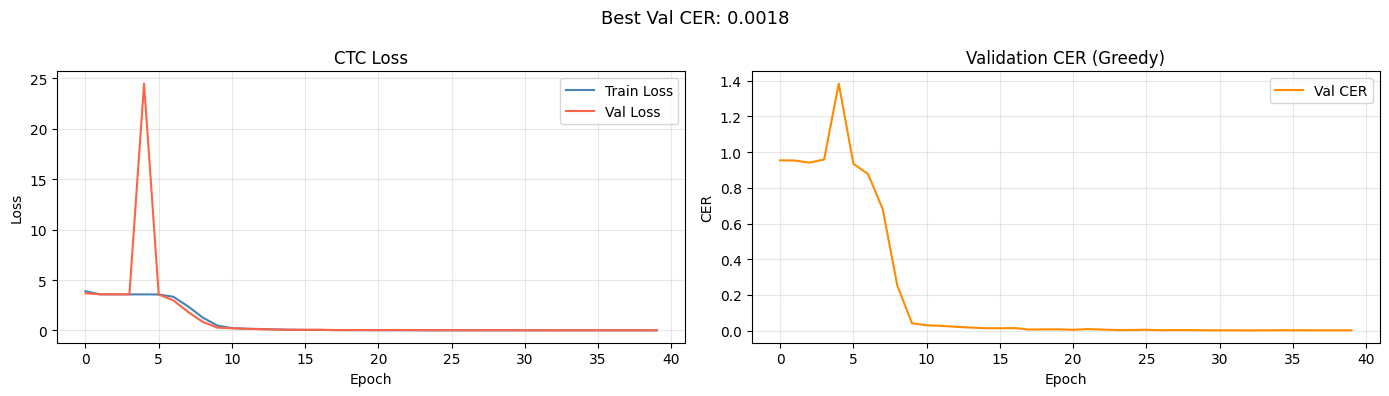

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('CTC Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_cer'], color='darkorange', label='Val CER')
axes[1].set_title('Validation CER (Greedy)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CER')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Best Val CER: {best_cer:.4f}', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=110)
plt.show()

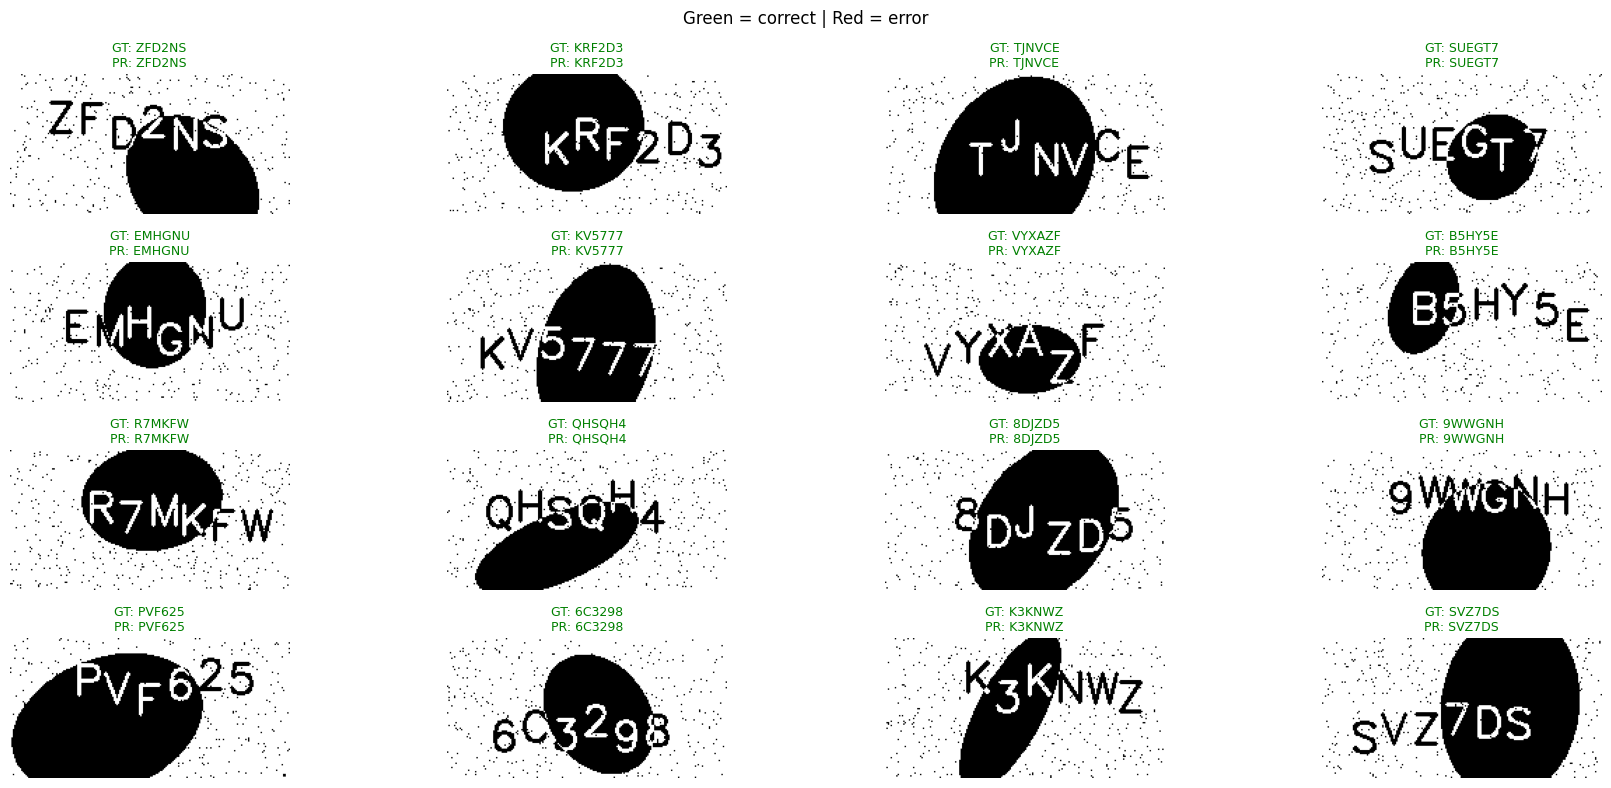

In [29]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

imgs, lbls = next(iter(val_loader))
imgs = imgs.to(DEVICE)

with torch.no_grad():
    log_probs = model(imgs)

batch_preds = decode_beam_batch(log_probs)

fig, axes = plt.subplots(4, 4, figsize=(18, 8))
for i, ax in enumerate(axes.flatten()):
    if i >= len(imgs): break
    pred   = batch_preds[i]
    target = decode_label(lbls[i])
    color  = 'green' if pred == target else 'red'
    ax.imshow(imgs[i].cpu().squeeze(), cmap='gray')
    ax.set_title(f"GT: {target}\nPR: {pred}", color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Green = correct | Red = error', fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/qualitative_check.png", dpi=110)
plt.show()

In [30]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(DEVICE)
        log_probs = model(imgs)

        batch_preds = decode_beam_batch(log_probs)

        for i in range(imgs.shape[0]):
            all_preds.append(batch_preds[i])
            all_targets.append(decode_label(lbls[i]))

beam_cer = compute_cer(all_preds, all_targets)
print(f"Greedy CER (best epoch): {best_cer:.4f}")
print(f"Beam Search CER: {beam_cer:.4f}")

exact = sum(p == t for p, t in zip(all_preds, all_targets))
print(f"Exact match accuracy: {exact}/{len(all_targets)} ({100*exact/len(all_targets):.2f}%)")

Greedy CER (best epoch): 0.0018
Beam Search CER: 0.0018
Exact match accuracy: 1978/2000 (98.90%)


In [32]:
import csv

SUBMISSION_PATH = f"{OUTPUT_DIR}/submission_priyanshu_24113102.csv"

with open(SUBMISSION_PATH, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'prediction'])
    writer.writeheader()
    writer.writerows(predictions)

print(f"Submission saved: {SUBMISSION_PATH}")

pd.read_csv(SUBMISSION_PATH).head(10)

Submission saved: /kaggle/working/outputs/submission_priyanshu_24113102.csv


,image,prediction
0,test-0.png,QVTQ8A
1,test-1.png,7PSW9D
2,test-10.png,7DUP98
3,test-100.png,75Z4WT
4,test-1000.png,QAKZ7V
5,test-1001.png,R6MERY
6,test-1002.png,CHXX67
7,test-1003.png,9NV2WP
8,test-1004.png,F56TDZ
9,test-1005.png,FFTFRX
